## 1. 问题背景

我们现在不是只有一个输入特征，而是有两个特征：

- `size`：房屋面积
- `bedroom`：卧室数量

因此模型变成：

$$
\hat y = w_1 x_1 + w_2 x_2 + b
$$

如果写成向量形式：

$$
\hat y = Xw + b
$$

其中：

$$
X =
\begin{bmatrix}
x_1^{(1)} & x_2^{(1)} \\
x_1^{(2)} & x_2^{(2)} \\
\vdots & \vdots \\
x_1^{(n)} & x_2^{(n)}
\end{bmatrix},
\qquad
w =
\begin{bmatrix}
w_1 \\
w_2
\end{bmatrix}
$$

在这个例子中，我们人为设定真实模型：

$$
y = 3000 \cdot \text{size} + 20000 \cdot \text{bedroom} + 50000 + \text{noise}
$$

然后让模型通过训练去“学会”这些参数。

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 2. 生成合成数据

In [2]:
# ==========================
# 1. Generate synthetic data
# ==========================

np.random.seed(0)

n = 200

# features
size = np.random.normal(100, 20, n)
bedroom = np.random.randint(1, 5, n)

# true model
true_w1 = 3000
true_w2 = 20000
true_b = 50000

noise = np.random.normal(0, 10000, n)

price = true_w1 * size + true_w2 * bedroom + true_b + noise

# stack features
X = np.column_stack([size, bedroom])
y = price

print("X shape =", X.shape)
print("y shape =", y.shape)
print("前3个样本 X =")
print(X[:3])
print("前3个标签 y =")
print(y[:3])

X shape = (200, 2)
y shape = (200,)
前3个样本 X =
[[135.28104692   1.        ]
 [108.00314417   4.        ]
 [119.57475968   3.        ]]
前3个标签 y =
[480780.55853155 452848.39311169 448417.43436853]


### 公式和代码对应

真实数据生成公式：

$$
y = 3000 \cdot \text{size} + 20000 \cdot \text{bedroom} + 50000 + \text{noise}
$$

对应代码行：

- `price = true_w1 * size + true_w2 * bedroom + true_b + noise`

矩阵特征拼接：

$$
X = [\text{size}, \text{bedroom}]
$$

对应代码行：

- `X = np.column_stack([size, bedroom])`

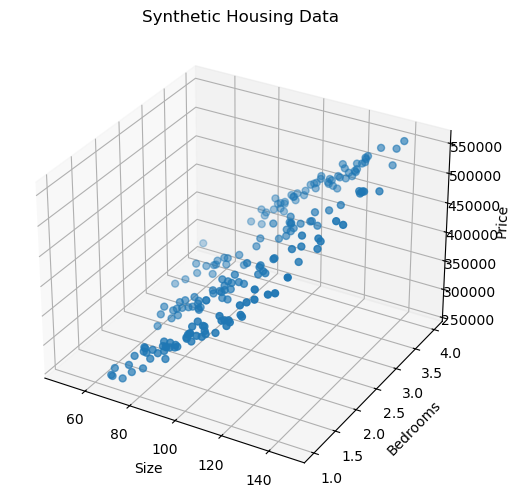

In [3]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(size, bedroom, price, s=25)
ax.set_title("Synthetic Housing Data")
ax.set_xlabel("Size")
ax.set_ylabel("Bedrooms")
ax.set_zlabel("Price")
plt.show()

## 3. 模型公式

对第 $i$ 个样本，预测值为：

$$
\hat y^{(i)} = w_1 x_1^{(i)} + w_2 x_2^{(i)} + b
$$

写成矩阵形式就是：

$$
\hat y = Xw + b
$$

在 NumPy 中：

- `X @ w` 表示矩阵乘法
- `+ b` 表示给每个样本都加上偏置项

## 4. 损失函数

我们使用均方误差（MSE）：

$$
J(w,b) = \frac{1}{n}\sum_{i=1}^{n}(\hat y^{(i)} - y^{(i)})^2
$$

把模型代入：

$$
J(w,b) = \frac{1}{n}\sum_{i=1}^{n}(w_1x_1^{(i)} + w_2x_2^{(i)} + b - y^{(i)})^2
$$

令误差向量为：

$$
e = \hat y - y
$$

那么损失可以写成：

$$
J = \frac{1}{n}\sum_{i=1}^{n} e_i^2
$$

## 5. 梯度推导

### 5.1 对参数向量 $w$ 求梯度

由于：

$$
\hat y = Xw + b
$$

误差向量：

$$
e = Xw + b - y
$$

损失函数：

$$
J(w,b) = \frac{1}{n} e^T e
$$

对 $w$ 求导可得：

$$
\frac{\partial J}{\partial w} = \frac{2}{n} X^T e
$$

也就是：

$$
dw = \frac{2}{n} X^T(\hat y - y)
$$

---

### 5.2 对偏置 $b$ 求梯度

因为每个样本都包含一个相同的偏置项，所以：

$$
\frac{\partial J}{\partial b}
=
\frac{2}{n}\sum_{i=1}^{n}(\hat y^{(i)} - y^{(i)})
$$

也就是：

$$
db = \frac{2}{n}\sum_{i=1}^{n} e_i
$$

## 6. 梯度下降更新公式

参数更新规则为：

$$
w \leftarrow w - \alpha dw
$$

$$
b \leftarrow b - \alpha db
$$

其中：

- $\alpha$ 是学习率 `lr`
- `dw` 是权重梯度
- `db` 是偏置梯度

## 7. 初始化参数

In [4]:
# ==========================
# 2. Initialize parameters
# ==========================

w = np.zeros(2)
b = 0

lr = 1e-6
epochs = 200

loss_history = []

print("初始 w =", w)
print("初始 b =", b)

初始 w = [0. 0.]
初始 b = 0


### 公式和代码对应

参数初始化：

$$
w =
\begin{bmatrix}
0 \\
0
\end{bmatrix},
\qquad b = 0
$$

对应代码行：

- `w = np.zeros(2)`
- `b = 0`

学习率与训练轮数：

- `lr = 1e-6`
- `epochs = 200`

## 8. 梯度下降训练主循环

In [5]:
# ==========================
# 3. Gradient Descent
# ==========================

for i in range(epochs):

    # (1) prediction
    y_pred = X @ w + b

    # (2) error
    error = y_pred - y

    # (3) loss
    loss = np.mean(error ** 2)
    loss_history.append(loss)

    # (4) gradients
    dw = (2 / n) * (X.T @ error)
    db = (2 / n) * np.sum(error)

    # (5) update
    w = w - lr * dw
    b = b - lr * db

print(f"learned parameters: w = {w} , b = {b}")

learned parameters: w = [3877.28302329  104.27624691] , b = 38.133141129202414


## 9. 训练循环中每一步的“公式 ↔ 代码行”对应

下面是最重要的部分。

### 9.1 预测值

数学公式：

$$
\hat y = Xw + b
$$

对应代码行：

```python
y_pred = X @ w + b
```

---

### 9.2 误差

数学公式：

$$
e = \hat y - y
$$

对应代码行：

```python
error = y_pred - y
```

---

### 9.3 损失函数

数学公式：

$$
J(w,b) = \frac{1}{n}\sum_{i=1}^{n}(\hat y^{(i)} - y^{(i)})^2
$$

对应代码行：

```python
loss = np.mean(error ** 2)
```

---

### 9.4 对 $w$ 的梯度

数学公式：

$$
dw = \frac{2}{n}X^T(\hat y - y)
$$

对应代码行：

```python
dw = (2 / n) * (X.T @ error)
```

---

### 9.5 对 $b$ 的梯度

数学公式：

$$
db = \frac{2}{n}\sum_{i=1}^{n}(\hat y^{(i)} - y^{(i)})
$$

对应代码行：

```python
db = (2 / n) * np.sum(error)
```

---

### 9.6 参数更新

数学公式：

$$
w \leftarrow w - \alpha dw
$$

$$
b \leftarrow b - \alpha db
$$

对应代码行：

```python
w = w - lr * dw
b = b - lr * db
```

## 10. 损失曲线可视化

如果梯度下降有效，那么训练过程中 loss 应逐步减小。

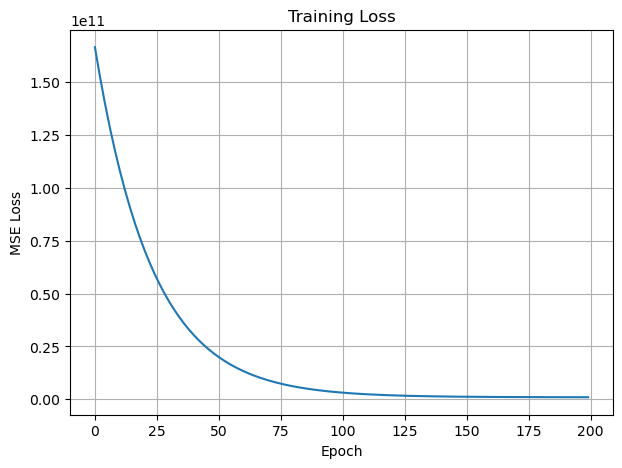

In [6]:
# ==========================
# 4. Plot loss
# ==========================

plt.figure(figsize=(7, 5))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss")
plt.grid(True)
plt.show()

### 公式和代码对应

损失历史记录：

- `loss_history.append(loss)`

画图代码：

- `plt.plot(loss_history)`

这个图对应的是：

$$
J^{(0)}, J^{(1)}, J^{(2)}, \dots, J^{(\text{epochs})}
$$

也就是每一轮训练后的损失值变化。

## 11. 三维可视化：数据点与拟合平面

由于这里有两个输入特征，所以最终模型是一个平面：

$$
\hat y = w_1 \cdot \text{size} + w_2 \cdot \text{bedroom} + b
$$

我们把它画到三维坐标系里：

- x 轴：`size`
- y 轴：`bedroom`
- z 轴：`price`

这样就能看到模型学到的平面是否贴近数据点。

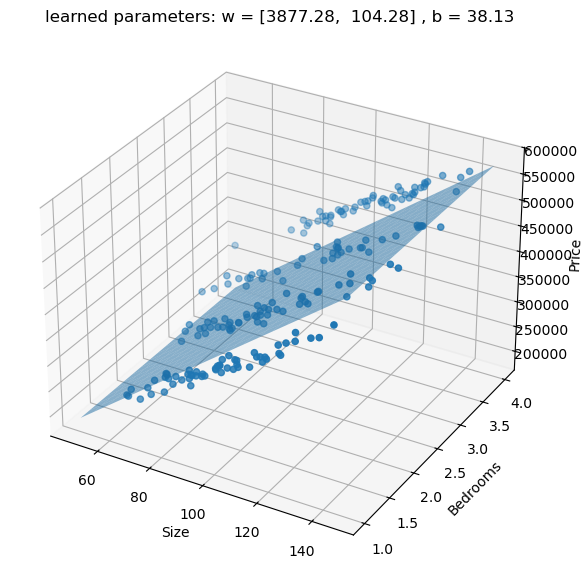

In [7]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

# scatter data
ax.scatter(size, bedroom, price)

# build grid
size_grid, bed_grid = np.meshgrid(
    np.linspace(size.min(), size.max(), 20),
    np.linspace(bedroom.min(), bedroom.max(), 20)
)

# predicted plane
price_pred = w[0] * size_grid + w[1] * bed_grid + b

# plot plane
ax.plot_surface(size_grid, bed_grid, price_pred, alpha=0.5)

w_str = np.array2string(w, precision=2, separator=', ')
ax.set_title(f"learned parameters: w = {w_str} , b = {b:.2f}")
ax.set_xlabel("Size")
ax.set_ylabel("Bedrooms")
ax.set_zlabel("Price")

plt.show()

## 14. 关键知识点总结

### 模型
$$
\hat y = Xw + b
$$

### 损失函数
$$
J(w,b)=\frac{1}{n}\sum_{i=1}^{n}(\hat y^{(i)}-y^{(i)})^2
$$

### 梯度
$$
dw = \frac{2}{n}X^T(\hat y-y)
$$

$$
db = \frac{2}{n}\sum_{i=1}^{n}(\hat y^{(i)}-y^{(i)})
$$

### 更新规则
$$
w \leftarrow w - \alpha dw
$$

$$
b \leftarrow b - \alpha db
$$

### 代码中的核心 6 行
```python
y_pred = X @ w + b
error = y_pred - y
loss = np.mean(error ** 2)
dw = (2 / n) * (X.T @ error)
db = (2 / n) * np.sum(error)
w = w - lr * dw
b = b - lr * db
```